In [ ]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("arnablaha05/deep-pcb")
print("Downloaded to cache:", path)

destination = "/content/DeepPCB"
if not os.path.exists(destination):
    shutil.copytree(path, destination)
    print("Dataset copied to main files section successfully!")

DATASET_PATH = destination

100%|██████████| 6.96G/6.96G [01:32<00:00, 81.0MB/s]

Extracting files...


Downloaded to cache: /root/.cache/kagglehub/datasets/arnablaha05/deep-pcb/versions/1
Dataset copied to main files section successfully!


In [ ]:
import glob

all_files = glob.glob("/content/DeepPCB/**/*.*", recursive=True)
images = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

print(f"Total Images Found on Disk: {len(images)}")
if len(images) > 0:
    print("Sample Image Paths:")
    for img in images[:5]:
        print(" ->", img)

Total Images Found on Disk: 5004
Sample Image Paths:
 -> /content/DeepPCB/PKU-Market-PCB(Data enhanced version)/test/images/04_short_13_1.jpg
 -> /content/DeepPCB/PKU-Market-PCB(Data enhanced version)/test/images/07_missing_hole_01_1.jpg
 -> /content/DeepPCB/PKU-Market-PCB(Data enhanced version)/test/images/06_spurious_copper_05_1.jpg
 -> /content/DeepPCB/PKU-Market-PCB(Data enhanced version)/test/images/05_short_07_1.jpg
 -> /content/DeepPCB/PKU-Market-PCB(Data enhanced version)/test/images/01_missing_hole_04_1.jpg


In [ ]:
import os
import glob
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2


train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


class PCBAuthenticPatchDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []  

    
        all_jpg_files = glob.glob(os.path.join(root_dir, "**", "*.jpg"), recursive=True)

        for img_path in all_jpg_files:
            label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")


            self.samples.append((img_path, 1, 'defective'))

            self.samples.append((img_path, 0, 'clean_patch'))

        self.labels = [s[1] for s in self.samples]

        print(f"Total Authentic PCB Patches Generated: {len(self.samples)}")
        print(f" - Defective Patches (Class 1): {sum(self.labels)}")
        print(f" - Normal/Clean Patches (Class 0): {len(self.labels) - sum(self.labels)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, patch_type = self.samples[idx]
        image = cv2.imread(img_path)

        if image is None:
            raise ValueError(f"Failed to load image at: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        if patch_type == 'clean_patch':
            
            image = cv2.flip(image, 1)

        label_tensor = torch.tensor(label, dtype=torch.float32)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label_tensor
dataset_root = "/content/DeepPCB"
full_dataset = PCBAuthenticPatchDataset(root_dir=dataset_root, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2,pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64,shuffle=False, num_workers=2,pin_memory=True)

print(f"\nDataLoaders Ready! Train Batches: {len(train_loader)} | Val Batches: {len(val_loader)}")

Total Authentic PCB Patches Generated: 10008
 - Defective Patches (Class 1): 5004
 - Normal/Clean Patches (Class 0): 5004

✅ DataLoaders Ready! Train Batches: 126 | Val Batches: 32


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)  # probability factor
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss
def get_pcb_model():
    weights = models.EfficientNet_B2_Weights.DEFAULT
    model = models.efficientnet_b2(weights=weights)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 1)  # Binary logit
    )
    return model


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_pcb_model().to(device)

# Using Custom Focal Loss
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

print(f"✅ Model & Loss Function Setup Complete!")
print(f"   - Architecture: EfficientNet-B2 (Pre-trained)")
print(f"   - Loss Function: Custom Focal Loss (alpha=0.25, gamma=2.0)")
print(f"   - Device: {device}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 160MB/s]


✅ Model & Loss Function Setup Complete!
   - Architecture: EfficientNet-B2 (Pre-trained)
   - Loss Function: Custom Focal Loss (alpha=0.25, gamma=2.0)
   - Device: cuda


In [ ]:
import time
import torch

def train_model_fast(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    best_val_loss = float('inf')
    save_path = "pcb_defect_efficientnet_focal.pth"

    scaler = torch.amp.GradScaler('cuda')

    print(" Fast Training Started (PyTorch 2.0+ AMP Clean Code)...\n" + "="*50)

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(images).squeeze(1)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_train_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss = running_train_loss / train_total
        train_acc = train_correct / train_total

        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                with torch.amp.autocast('cuda'):
                    outputs = model(images).squeeze(1)
                    loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = running_val_loss / val_total
        val_acc = val_correct / val_total
        elapsed = time.time() - start_time

        print(f"Epoch [{epoch+1}/{epochs}] ({elapsed:.1f}s) | "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

        # Best Model Save
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"   💾 Best Model Saved to '{save_path}'")

    print("="*50 + "\n✅ Fast Training Finished Successfully!")

# Run Fast Training
train_model_fast(model, train_loader, val_loader, criterion, optimizer, epochs=5)

🚀 Fast Training Started (PyTorch 2.0+ AMP Clean Code)...
Epoch [1/5] (391.1s) | Train Loss: 0.0180 - Train Acc: 84.11% | Val Loss: 0.0150 - Val Acc: 87.11%
   💾 Best Model Saved to 'pcb_defect_efficientnet_focal.pth'
Epoch [2/5] (369.6s) | Train Loss: 0.0141 - Train Acc: 88.23% | Val Loss: 0.0134 - Val Acc: 88.41%
   💾 Best Model Saved to 'pcb_defect_efficientnet_focal.pth'
Epoch [3/5] (366.4s) | Train Loss: 0.0111 - Train Acc: 91.81% | Val Loss: 0.0122 - Val Acc: 90.71%
   💾 Best Model Saved to 'pcb_defect_efficientnet_focal.pth'
Epoch [4/5] (369.8s) | Train Loss: 0.0083 - Train Acc: 94.19% | Val Loss: 0.0107 - Val Acc: 91.96%
   💾 Best Model Saved to 'pcb_defect_efficientnet_focal.pth'
Epoch [5/5] (367.6s) | Train Loss: 0.0066 - Train Acc: 95.53% | Val Loss: 0.0109 - Val Acc: 91.91%
✅ Fast Training Finished Successfully!


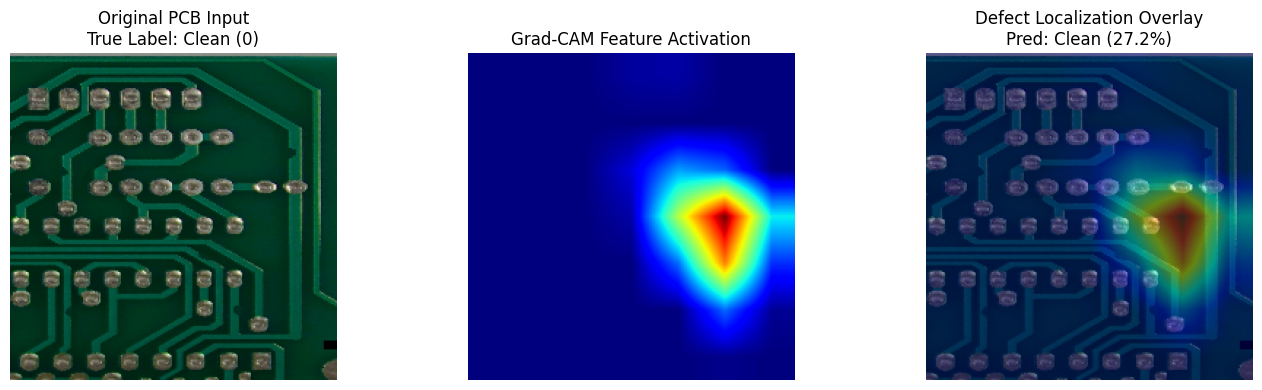

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, output):
        self.activations = output

    def save_gradient(self,  grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor):
        self.model.eval()
        output = self.model(input_tensor)

        self.model.zero_grad()
        output.backward()

        gradients = self.gradients.data.cpu().numpy()[0]
        activations = self.activations.data.cpu().numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0) 
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8) 

        confidence = torch.sigmoid(output).item()
        return cam, confidence

save_path = "pcb_defect_efficientnet_focal.pth"
model.load_state_dict(torch.load(save_path))
model.eval()

target_layer = model.features[-1]
grad_cam = GradCAM(model, target_layer)

sample_images, sample_labels = next(iter(val_loader))


idx = 0
input_img = sample_images[idx].unsqueeze(0).to(device)
true_label = int(sample_labels[idx].item())

heatmap, confidence = grad_cam.generate_heatmap(input_img)

img_np = sample_images[idx].cpu().numpy().transpose(1, 2, 0)
img_np = (img_np * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
img_np = np.clip(img_np, 0, 1)

heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
overlay = 0.6 * img_np + 0.4 * heatmap_colored

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original PCB Input\nTrue Label: {'Defective (1)' if true_label==1 else 'Clean (0)'}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Feature Activation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
pred_class = "Defective" if confidence > 0.5 else "Clean"
plt.title(f"Defect Localization Overlay\nPred: {pred_class} ({confidence*100:.1f}%)")
plt.axis("off")

plt.tight_layout()
plt.show()